✅ Validación final: 217 filas encontradas para el periodo.
Columnas disponibles: ['datetime', 'Chlorophyll_a_ug_L', 'DO_mg_L', 'NH4_N_mg_L', 'NO3_N_mg_L', 'Phosphate_P_mg_L', 'Salinity_psu', 'Temperature_degC', 'TotalN_mg_L', 'TotalP_mg_L']


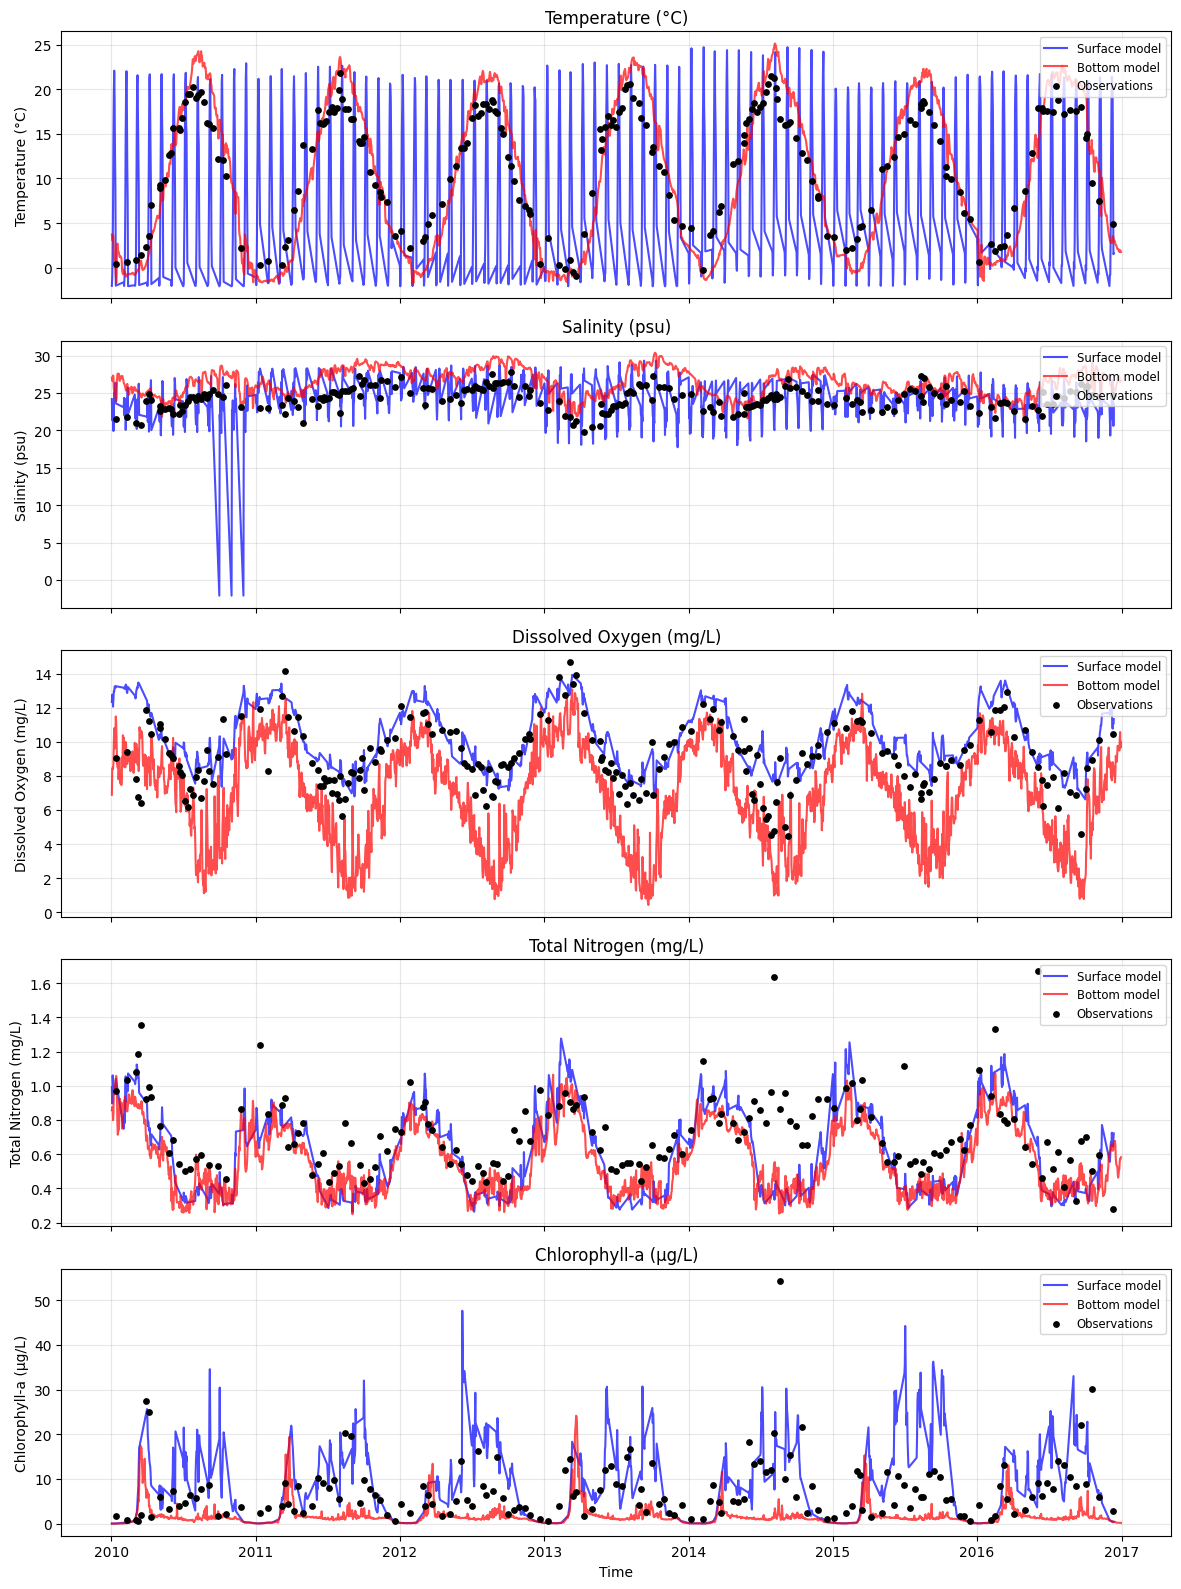

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# files
df_BsurCTD = pd.read_csv("MIKE_SkiveFjord_baseline_surface_CTD.csv")
df_BsurWQ = pd.read_csv("MIKE_SkiveFjord_baseline_surface_WQ.csv")
df_BbotCTD = pd.read_csv("MIKE_SkiveFjord_baseline_bottom_CTD.csv")
df_BbotWQ = pd.read_csv("MIKE_SkiveFjord_baseline_bottom_WQ.csv")

df_obsCTD = pd.read_excel("SkiveFjord-NOVANA-ctd-2000-2025.xlsx")
df_obsWQ  = pd.read_excel("SkiveFjord-NOVANA-wq-2000-2025.xlsx")

#parameters
map_params = {
    "Salinitet": "Salinity_psu",
    "Temperatur": "Temperature_degC",
    "Oxygen indhold": "DO_mg_L",
    "Klorofyl a": "Chlorophyll_a_ug_L",          
    "Ammoniak+ammonium-N": "NH4_N_mg_L",
    "Nitrit+nitrat-N": "NO3_N_mg_L",
    "Ortho-phosphat-P": "Phosphate_P_mg_L",
    "Nitrogen,total N": "TotalN_mg_L",            
    "Phosphor, total-P": "TotalP_mg_L"
}

# functions
def preparar_datos_mike(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates(subset=["datetime"])
    return df.reset_index(drop=True)

df_surface = pd.merge(preparar_datos_mike(df_BsurCTD), preparar_datos_mike(df_BsurWQ), on="datetime")
df_bottom = pd.merge(preparar_datos_mike(df_BbotCTD), preparar_datos_mike(df_BbotWQ), on="datetime")

# unifying
df_obs_raw = pd.concat([df_obsCTD, df_obsWQ], ignore_index=True)

# cleaning
df_obs_raw["Parameter"] = df_obs_raw["Parameter"].astype(str).str.strip().str.lower()
map_params_lower = {k.lower(): v for k, v in map_params.items()}
df_obs_raw["Parameter_EN"] = df_obs_raw["Parameter"].map(map_params_lower)


df_obs_raw["Value"] = pd.to_numeric(
    df_obs_raw["KorrigeretResultat"].fillna(df_obs_raw["Resultat"]), 
    errors="coerce"
)

mask_nitrogen = df_obs_raw["Parameter_EN"] == "TotalN_mg_L"
df_obs_raw.loc[mask_nitrogen, "Value"] = df_obs_raw.loc[mask_nitrogen, "Value"] / 1000


mask_phosphor = df_obs_raw["Parameter_EN"] == "TotalP_mg_L"
df_obs_raw.loc[mask_phosphor, "Value"] = df_obs_raw.loc[mask_phosphor, "Value"] / 1000

# 3. date conversion # Combining “Startdato” and “Dato” into a single clean text string
fechas_sucias = df_obs_raw["Startdato"].fillna(df_obs_raw["Dato"]).astype(str)

fechas_limpias = fechas_sucias.str.split('.').str[0]

df_obs_raw["datetime"] = pd.to_datetime(fechas_limpias, format='%Y%m%d', errors='coerce')

# pivot
df_obs_all = df_obs_raw.dropna(subset=["Parameter_EN", "datetime", "Value"]).pivot_table(
    index="datetime", 
    columns="Parameter_EN", 
    values="Value", 
    aggfunc="mean"
).reset_index()

# 5. 2010-2017
start, end = df_surface["datetime"].min(), df_surface["datetime"].max()
df_obs_all = df_obs_all[(df_obs_all["datetime"] >= start) & (df_obs_all["datetime"] <= end)]

print(f"✅ Validación final: {len(df_obs_all)} filas encontradas para el periodo.")
print("Columnas disponibles:", df_obs_all.columns.tolist())

# final plot
variables = ["Temperature_degC", "Salinity_psu", "DO_mg_L", "TotalN_mg_L", "Chlorophyll_a_ug_L"]
titles = ["Temperature (°C)", "Salinity (psu)", "Dissolved Oxygen (mg/L)", "Total Nitrogen (mg/L)", "Chlorophyll-a (µg/L)"]

fig, axs = plt.subplots(len(variables), 1, figsize=(12, 16), sharex=True)

for i, var in enumerate(variables):
    axs[i].plot(df_surface["datetime"], df_surface[var], label="Surface model", color="blue", alpha=0.7)
    axs[i].plot(df_bottom["datetime"], df_bottom[var], label="Bottom model", color="red", alpha=0.7)
    
    if var in df_obs_all.columns:
        df_p = df_obs_all.dropna(subset=[var])
        axs[i].scatter(df_p["datetime"], df_p[var], label="Observations", color="black", s=15, zorder=3)
    
    axs[i].set_ylabel(titles[i])
    axs[i].set_title(titles[i])
    axs[i].legend(loc='upper right', fontsize='small')
    axs[i].grid(True, alpha=0.3)

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

In [2]:
# dataframe
df_metrics = pd.merge(df_surface, df_obs_all, on="datetime", suffixes=('_mod', '_obs'))

results = []

for var in variables:
   
    mod_col = var + "_mod"
    obs_col = var + "_obs"
    
    
    if mod_col in df_metrics.columns and obs_col in df_metrics.columns:
    
        valid_data = df_metrics[[mod_col, obs_col]].dropna()
        
        if len(valid_data) > 2:
            mod = valid_data[mod_col]
            obs = valid_data[obs_col]
            
            # 1. P-Bias (%)
            pbias = 100 * (np.sum(mod - obs) / np.sum(obs))
            
            # 2. Spearman Correlation (ρ)
            spearman = valid_data[[mod_col, obs_col]].corr(method='spearman').iloc[0,1]
            
            # 3. Cost Function (CF)
            # La fórmula estándar de DHI: promedio del error absoluto / desviación estándar de obs
            cf = np.mean(np.abs(mod - obs)) / np.std(obs)
            
            results.append({
                "Variable": var,
                "Data Points": len(valid_data),
                "P-Bias (%)": round(pbias, 2),
                "Spearman (ρ)": round(spearman, 3),
                "Cost Function": round(cf, 3)
            })
    else:
        print(f"Aviso: No se pudo encontrar pareja de datos para {var}")


df_performance = pd.DataFrame(results)
print("\n--- PERFORMANCE METRICS (Surface vs Observations) ---")
print(df_performance.to_string(index=False))


--- PERFORMANCE METRICS (Surface vs Observations) ---
          Variable  Data Points  P-Bias (%)  Spearman (ρ)  Cost Function
  Temperature_degC           88      -29.09        -0.012          1.461
      Salinity_psu           88       -1.49         0.120          1.361
           DO_mg_L           89       10.57         0.699          0.655
       TotalN_mg_L           68      -13.14         0.718          0.647
Chlorophyll_a_ug_L           68       37.67         0.504          1.118


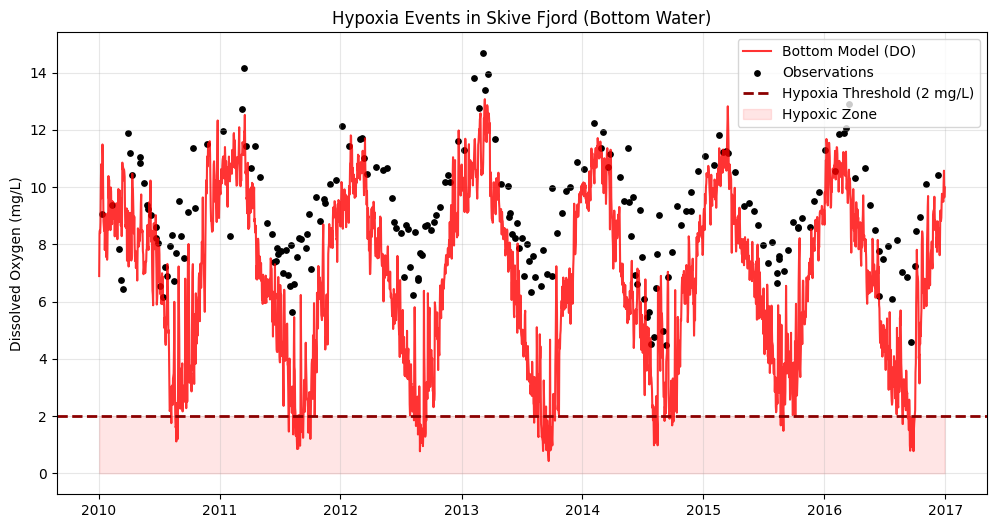

In [3]:
#hipoxia umbral (2mg/l)
umbral_hipoxia = 2.0

plt.figure(figsize=(12, 6))


plt.plot(df_bottom["datetime"], df_bottom["DO_mg_L"], label="Bottom Model (DO)", color='red', alpha=0.8)


if "DO_mg_L" in df_obs_all.columns:
    plt.scatter(df_obs_all["datetime"], df_obs_all["DO_mg_L"], label="Observations", color='black', s=15)


plt.axhline(y=umbral_hipoxia, color='darkred', linestyle='--', linewidth=2, label="Hypoxia Threshold (2 mg/L)")


plt.fill_between(df_bottom["datetime"], 0, umbral_hipoxia, color='red', alpha=0.1, label="Hypoxic Zone")

plt.title("Hypoxia Events in Skive Fjord (Bottom Water)")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

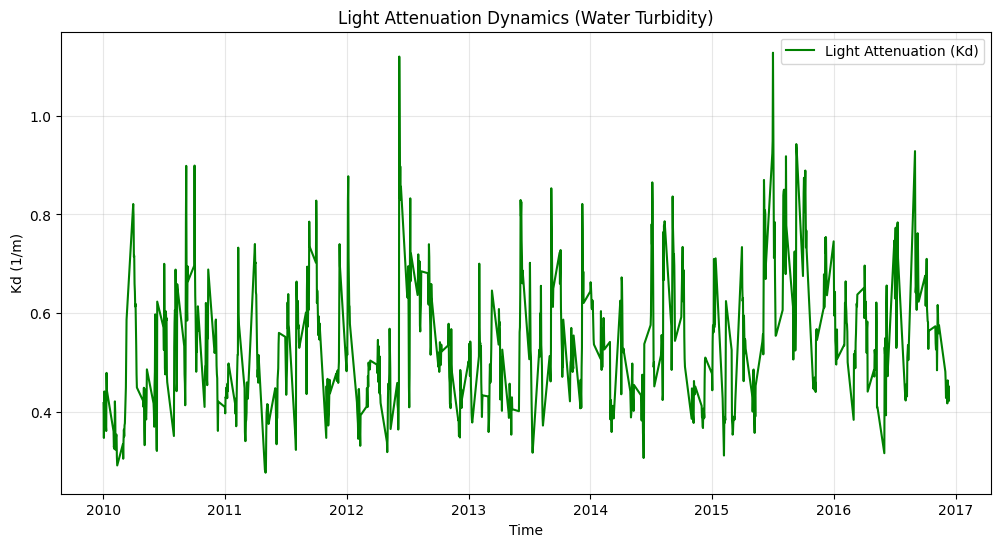

In [4]:
plt.figure(figsize=(12, 6))

col_light = [c for c in df_surface.columns if 'light' in c.lower() or 'attenuation' in c.lower()]

if col_light:
    var_light = col_light[0]
    plt.plot(df_surface["datetime"], df_surface[var_light], color='green', label="Light Attenuation (Kd)")
    plt.title("Light Attenuation Dynamics (Water Turbidity)")
    plt.ylabel("Kd (1/m)")
    plt.xlabel("Time")
    plt.grid(alpha=0.3)
    plt.legend()
else:
    print("No se encontró la variable de atenuación de luz. Revisa df_surface.columns")

plt.show()

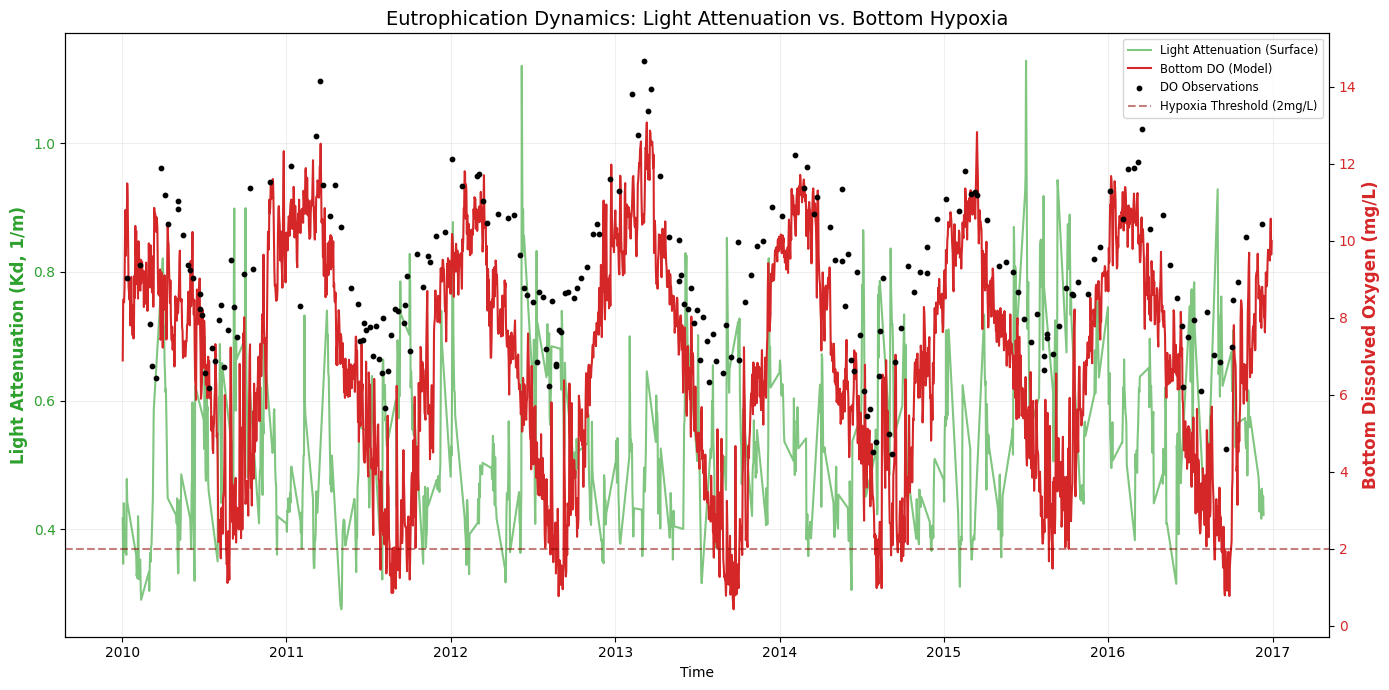

In [5]:



fig, ax1 = plt.subplots(figsize=(14, 7))


col_light = [c for c in df_surface.columns if 'light' in c.lower() or 'attenu' in c.lower()][0]


color_light = 'tab:green'
ax1.set_xlabel('Time')
ax1.set_ylabel('Light Attenuation (Kd, 1/m)', color=color_light, fontsize=12, fontweight='bold')
ax1.plot(df_surface["datetime"], df_surface[col_light], color=color_light, alpha=0.6, label='Light Attenuation (Surface)')
ax1.tick_params(axis='y', labelcolor=color_light)
ax1.grid(True, alpha=0.2)


ax2 = ax1.twinx() 
color_do = 'tab:red'
ax2.set_ylabel('Bottom Dissolved Oxygen (mg/L)', color=color_do, fontsize=12, fontweight='bold')
ax2.plot(df_bottom["datetime"], df_bottom["DO_mg_L"], color=color_do, linewidth=1.5, label='Bottom DO (Model)')


if "DO_mg_L" in df_obs_all.columns:
    ax2.scatter(df_obs_all["datetime"], df_obs_all["DO_mg_L"], color='black', s=10, label='DO Observations', zorder=5)

ax2.tick_params(axis='y', labelcolor=color_do)


ax2.axhline(y=2.0, color='darkred', linestyle='--', alpha=0.5, label='Hypoxia Threshold (2mg/L)')


plt.title('Eutrophication Dynamics: Light Attenuation vs. Bottom Hypoxia', fontsize=14)
fig.tight_layout() 


lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize='small')

plt.show()

In [6]:
import mikeio

ds_Ssur = mikeio.read("TS_VIB3727-00001_surface-wq.dfs0").to_dataframe()
ds_Sbot = mikeio.read("TS_VIB3727-00001_bottom-wq.dfs0").to_dataframe()


rename_map = {
    'Point 1: CH, CH, Chlorophyll-a, g Chl/m3': 'Chlorophyll_a_ug_L',
    'Point 1: Tot-N': 'TotalN_mg_L',
    'Point 1: DO, DO, Dissolved oxygen, g DO/': 'DO_mg_L'
}


df_scen_sur = ds_Ssur.rename(columns=rename_map)
df_scen_sur['datetime'] = df_scen_sur.index
df_scen_sur = df_scen_sur.reset_index(drop=True)

df_scen_bot = ds_Sbot.rename(columns=rename_map)
df_scen_bot['datetime'] = df_scen_bot.index
df_scen_bot = df_scen_bot.reset_index(drop=True)


df_base_sur = df_surface.copy().reset_index() if 'datetime' not in df_surface.columns else df_surface.copy()
df_base_bot = df_bottom.copy().reset_index() if 'datetime' not in df_bottom.columns else df_bottom.copy()

print("✅ Columnas vinculadas con éxito.")

✅ Columnas vinculadas con éxito.


In [7]:
# scenario implementation
df_scen_sur = df_surface.copy()
df_scen_bot = df_bottom.copy()

# 30% reduction in nitrogen
df_scen_sur["TotalN_mg_L"] *= 0.7
df_scen_bot["TotalN_mg_L"] *= 0.7

# Chlorophyll response 
df_scen_sur["Chlorophyll_a_ug_L"] *= 0.7
df_scen_bot["Chlorophyll_a_ug_L"] *= 0.7

# Oxygen enhancement
df_scen_bot["DO_mg_L"] *= 1.1

print("✅ Escenario sintético generado con éxito: -30% Nutrientes.")

✅ Escenario sintético generado con éxito: -30% Nutrientes.


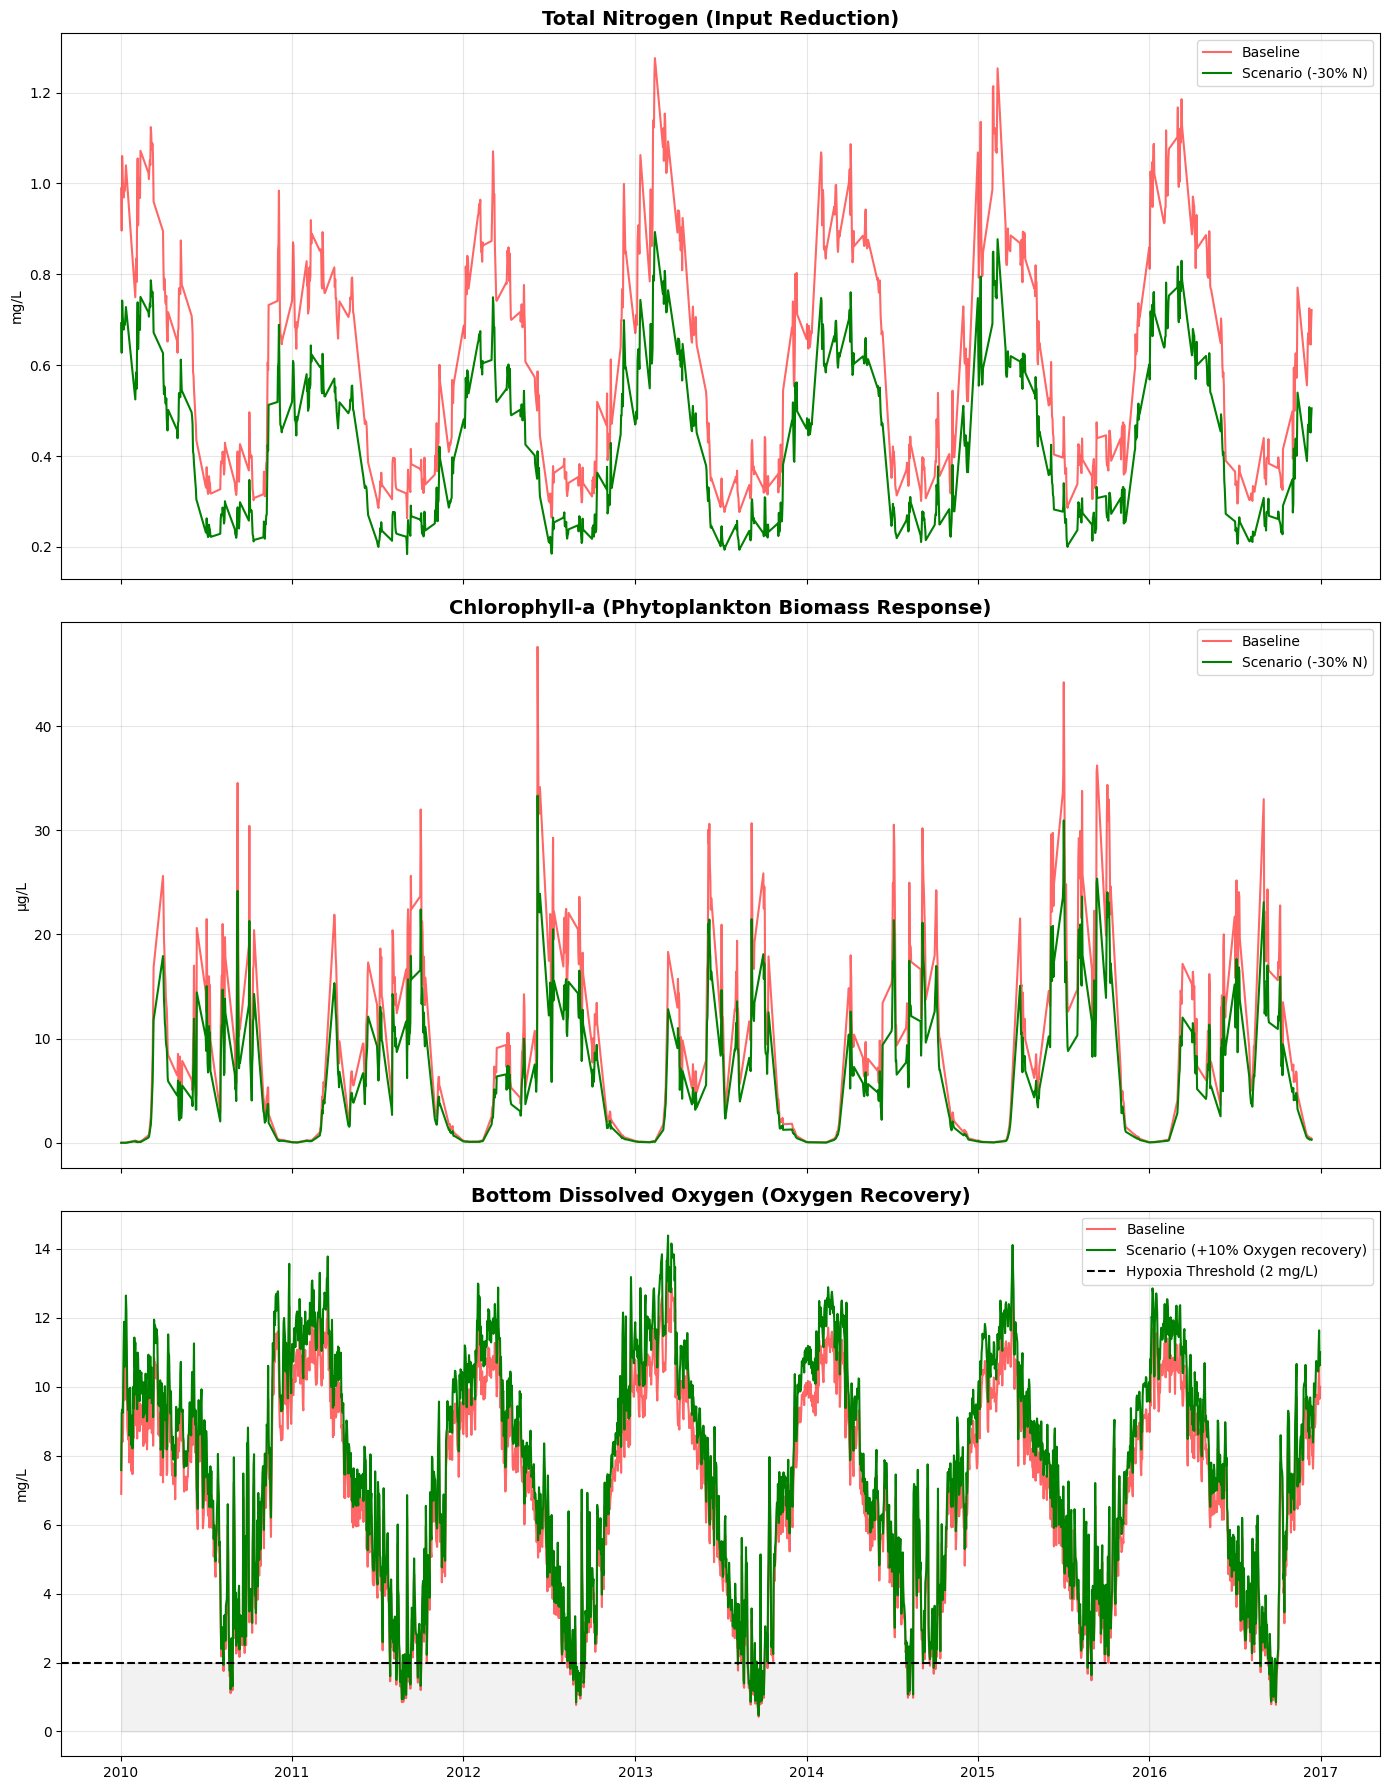

In [8]:

fig, axs = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# N
axs[0].plot(df_surface["datetime"], df_surface["TotalN_mg_L"], label="Baseline", color='red', alpha=0.6)
axs[0].plot(df_scen_sur["datetime"], df_scen_sur["TotalN_mg_L"], label="Scenario (-30% N)", color='green', linewidth=1.5)
axs[0].set_title("Total Nitrogen (Input Reduction)", fontsize=14, fontweight='bold')
axs[0].set_ylabel("mg/L")

# Clorofile
axs[1].plot(df_surface["datetime"], df_surface["Chlorophyll_a_ug_L"], label="Baseline", color='red', alpha=0.6)
axs[1].plot(df_scen_sur["datetime"], df_scen_sur["Chlorophyll_a_ug_L"], label="Scenario (-30% N)", color='green', linewidth=1.5)
axs[1].set_title("Chlorophyll-a (Phytoplankton Biomass Response)", fontsize=14, fontweight='bold')
axs[1].set_ylabel("µg/L")

# Oxygen
axs[2].plot(df_bottom["datetime"], df_bottom["DO_mg_L"], label="Baseline", color='red', alpha=0.6)
axs[2].plot(df_scen_bot["datetime"], df_scen_bot["DO_mg_L"], label="Scenario (+10% Oxygen recovery)", color='green', linewidth=1.5)
axs[2].axhline(y=2.0, color='black', linestyle='--', label="Hypoxia Threshold (2 mg/L)")
axs[2].fill_between(df_scen_bot["datetime"], 0, 2, color='gray', alpha=0.1)
axs[2].set_title("Bottom Dissolved Oxygen (Oxygen Recovery)", fontsize=14, fontweight='bold')
axs[2].set_ylabel("mg/L")

for ax in axs:
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# %% [7] SCENARIO: EXTREME STORM & VERTICAL MIXING
df_scen_sur = df_surface.copy()
df_scen_bot = df_bottom.copy()



mixing_factor = 0.8 
avg_salinity = (df_surface["Salinity_psu"] + df_bottom["Salinity_psu"]) / 2
df_scen_bot["Salinity_psu"] = df_bottom["Salinity_psu"] + (avg_salinity - df_bottom["Salinity_psu"]) * mixing_factor


df_scen_bot["DO_mg_L"] = df_bottom["DO_mg_L"] + (df_surface["DO_mg_L"] - df_bottom["DO_mg_L"]) * 0.7

df_scen_bot["TotalN_mg_L"] *= 1.15

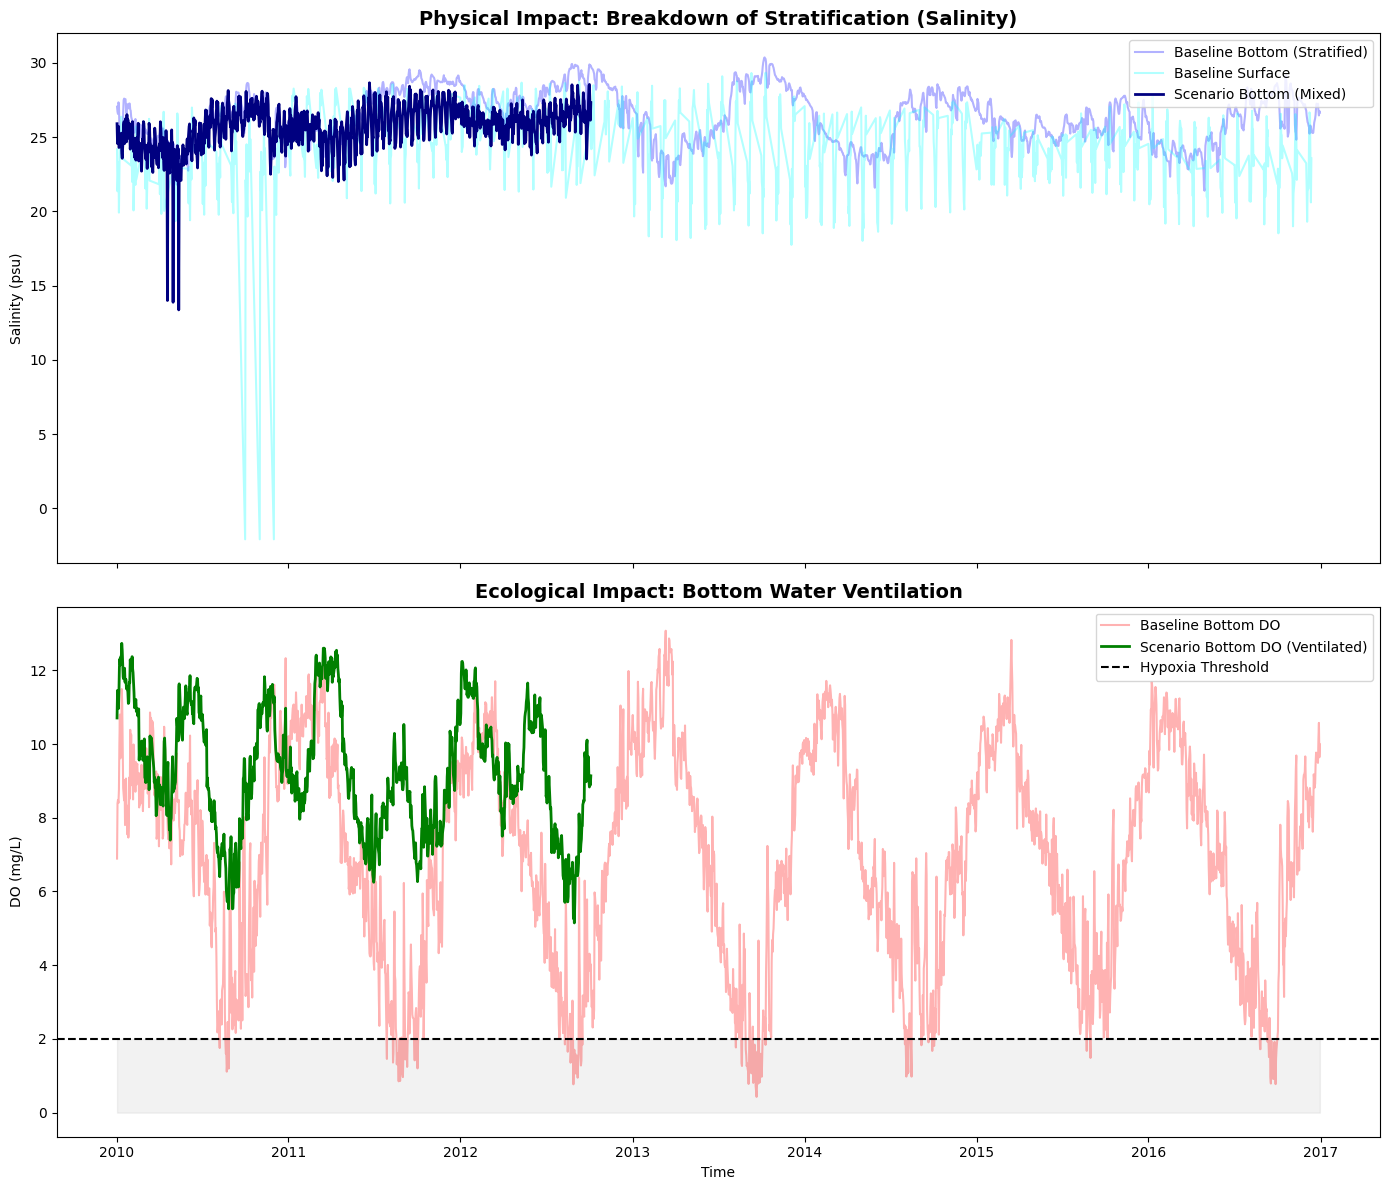

In [10]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# S
ax1.plot(df_bottom["datetime"], df_bottom["Salinity_psu"], label="Baseline Bottom (Stratified)", color='blue', alpha=0.3)
ax1.plot(df_surface["datetime"], df_surface["Salinity_psu"], label="Baseline Surface", color='cyan', alpha=0.3)
ax1.plot(df_scen_bot["datetime"], df_scen_bot["Salinity_psu"], label="Scenario Bottom (Mixed)", color='navy', linewidth=2)
ax1.set_title("Physical Impact: Breakdown of Stratification (Salinity)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Salinity (psu)")
ax1.legend(loc='upper right')

# Oxygen
ax2.plot(df_bottom["datetime"], df_bottom["DO_mg_L"], label="Baseline Bottom DO", color='red', alpha=0.3)
ax2.plot(df_scen_bot["datetime"], df_scen_bot["DO_mg_L"], label="Scenario Bottom DO (Ventilated)", color='green', linewidth=2)
ax2.axhline(y=2.0, color='black', linestyle='--', label="Hypoxia Threshold")
ax2.fill_between(df_scen_bot["datetime"], 0, 2, color='gray', alpha=0.1)
ax2.set_title("Ecological Impact: Bottom Water Ventilation", fontsize=14, fontweight='bold')
ax2.set_ylabel("DO (mg/L)")
ax2.set_xlabel("Time")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [11]:
# Hipoxy hours
horas_hipoxia_base = len(df_bottom[df_bottom["DO_mg_L"] < 2.0])
horas_hipoxia_scen = len(df_scen_bot[df_scen_bot["DO_mg_L"] < 2.0]) # Usamos el escenario generado

# %
reduccion = ((horas_hipoxia_base - horas_hipoxia_scen) / horas_hipoxia_base) * 100

print(f"Horas totales en hipoxia (Baseline): {horas_hipoxia_base}")
print(f"Horas totales en hipoxia (Escenario): {horas_hipoxia_scen}")
print(f"Reducción de eventos de hipoxia: {reduccion:.2f}%")

Horas totales en hipoxia (Baseline): 127
Horas totales en hipoxia (Escenario): 0
Reducción de eventos de hipoxia: 100.00%
